# Week 9 version  
GS on fine level  
Then projecting to a coarse level  
Then solving in that coarse level (using the inverse)  
Then projecting back to the fine level  
GS again  
Then CG  
Return solution  
Compare solution to known true answer  

Near the bottom of the notebook there are:  
checks that the A matrices are SPD and  
that A coarse is the same whether projected or made in the coarse space

In [12]:
# import necessary packages
from ngsolve import *
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import norm,inv
import time

In [13]:
# Report result
def print_norms(xi, A):
    # L2Norm
    l2n = xi.vec.Norm()
    # Energy norm
    enorm = sqrt(InnerProduct(xi.vec, A * xi.vec))
    # Since the "real solution" to our problem is zero, this is the distance from it
    # If we do a different problem, this wouldn't be the convergence 
    print(f'Convergence progress ||x||=', l2n, ', and ||x||_A=', enorm)

In [14]:
# Set up two levels of meshes
coarse_mesh = Mesh(unit_square.GenerateMesh(maxh=1/64))
fesc = H1(coarse_mesh, order=1, dirichlet="left|right")
fine_mesh = Mesh(coarse_mesh.ngmesh.Copy())
fesf = H1(fine_mesh, order=1, dirichlet="left|right")
fesf.mesh.Refine()
PT = fesf.Prolongation().CreateMatrix(fesf.mesh.levels-1) # I switched these to match PV
P = PT.CreateTranspose()

In [15]:
# Setup the PDE to solve
u, v = fesf.TnT()
a = BilinearForm(grad(u)*grad(v)*dx).Assemble()
f = LinearForm(fesf).Assemble()
a_fine = a.GetMatrixLevel()
# Initial iterate
x0 = CoefficientFunction(sin(pi*x)*sin(pi*y)+(1/10)*sin(10*pi*x)*sin(10*pi*y))

In [16]:
# Gauss Seidel Forward Smoothing
m = a_fine.CreateSmoother(fesf.FreeDofs(), GS=True)
xi = GridFunction(fesf)
xi.Set(-x0)
print_norms(xi, a_fine)
yi = GridFunction(fesf)
yi.Set(0, BND)
s = Draw(xi,fine_mesh,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})
smootha = a_fine
for i in range(1):
    smootha = m @ smootha
    smootha.Mult(xi.vec, yi.vec.data)
    xi.vec.data -= yi.vec
    #time.sleep(1) # for the visualization of the smoothing, annoying otherwise
    s.Redraw()

print_norms(xi, a_fine)

Convergence progress ||x||= 68.70770465151283 , and ||x||_A= 3.1518305427065987


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'transformations'…

Convergence progress ||x||= 68.62393039094874 , and ||x||_A= 3.0353838461964195


In [24]:
# The coarse space setup
phi, nu = fesc.TnT()
a_coarse = BilinearForm(grad(phi)*grad(nu)*dx).Assemble()
# the RHS of the coarse solve is the last iterate from the fine space, projected here
f_coarse = LinearForm(fesc)
f_coarse.vec.data += P * xi.vec
tempcoarseRHS = P * xi.vec
#prevec = f_coarse.vec.FV().NumPy()
f_coarse.Assemble()
#postvec = f_coarse.vec.FV().NumPy()
#print(postvec - prevec, " difference around assembly")
xcoarse = GridFunction(fesc)
#Draw(xcoarse,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})
# Solve via inverse
xcoarse.vec.data += a_coarse.mat.Inverse(freedofs=fesc.FreeDofs()) * tempcoarseRHS
Draw(xcoarse,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'transformations'…

BaseWebGuiScene

In [18]:
# Projecting solution from coarse space back to fine space
x_fine = GridFunction(fesf)
x_fine.Set(0, BND)
x_fine.vec.data += PT * xcoarse.vec
#Draw(x_fine,fine_mesh)
#print_norms(x_fine, a_fine)

In [19]:
# GS backward smoothing
m2 = a_fine.CreateSmoother(fesf.FreeDofs(), GS=True)
yfine = GridFunction(fesf)
yfine.Set(0, BND)
xi.vec.data = x_fine.vec.Copy()
s2 = Draw(xi,fine_mesh,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]},"deformation":0.5})
smootha = a_fine
for i in range(20):
    smootha = m2 @ smootha
    smootha.Mult(x_fine.vec, yfine.vec.data)
    xi.vec.data -= yfine.vec
    #time.sleep(1) # uncomment for visualization purposes, but keep hidden for normal work
    s2.Redraw()

print_norms(xi, a_fine)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'transformations'…

Convergence progress ||x||= 0.0 , and ||x||_A= 0.0


In [20]:
# Now do CG after the two-level
cgu = GridFunction(fesf)
cgu.Set(0,BND)
#Draw(cgu,fine_mesh,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]}})
solvers.BVP(bf=a, lf=f, gf=cgu, maxsteps=500, tol=1e-14)
print_norms(cgu, a_fine)
Draw(cgu,fine_mesh,settings={"camera": {"transformations": [{"type": "rotateX", "angle": -60}]}})

Convergence progress ||x||= 0.0 , and ||x||_A= 0.0


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'transformations'…

BaseWebGuiScene

Below, we have a function used to check if the A matrices at both levels are spd. They are.

In [21]:
# Testing if a matrix A is SPD via z^T A z > 0 with z = random vectors
def spd_check(A,fes,max_iter=10000):
    iter = 0
    w = 1
    while(w > 0 and iter < max_iter):
        z = GridFunction(fes)
        v = z.vec.CreateVector()
        v.SetRandom()
        z.vec.data = Projector(fes.FreeDofs(), True) * v
        w = GridFunction(fes)
        w = InnerProduct(z.vec, A * z.vec)
        if(w == 0):
            print('Matrix is not SPD')
            return False
        elif(w < 0):
            print('Matrix is not SPD')
            return False
        iter += 1
        #print(w)
    return True

fine_spd = spd_check(a_fine, fesf)
coarse_spd = spd_check(a_coarse.mat, fesc)
fine_spd, coarse_spd


(True, True)

Code to confirm that the A coarse matrices are the same whether projected from the fine space using P or created as the bilinear form of the coarse space

The difference between the two versions of A coarse is 5.984446939085212e-13


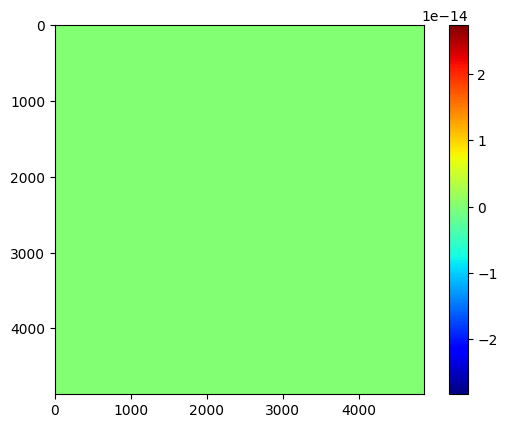

In [22]:
# comparing the two Acoarse matrices
alt_coarse = P @ a_fine @ PT
rows1, cols1, vals1 = a_coarse.mat.COO()
rows2, cols2, vals2 = alt_coarse.COO()

ac1 = sp.csr_matrix((vals1,(rows1,cols1)))
ac2 = sp.csr_matrix((vals2,(rows2,cols2)))
acdiff = ac1 - ac2
print("The difference between the two versions of A coarse is", norm(acdiff))
plt.imshow(acdiff.toarray(), cmap='jet')
plt.colorbar()
plt.show()
